# **Task 2: Predicting Customer Churn**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [ ]:
#1.Perform EDA

In [ ]:
df = pd.read_csv('/content/BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
df.shape

(10127, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [ ]:
# Missing values
print(df.isnull().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

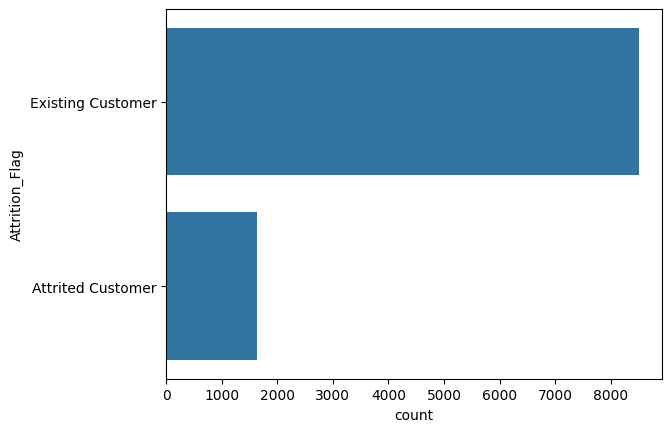

In [ ]:
sns.countplot(df['Attrition_Flag'])
plt.show()


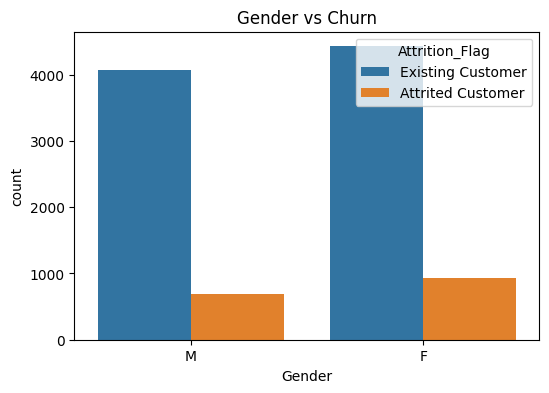

In [ ]:
# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x=df['Gender'], hue=df['Attrition_Flag'])
plt.title("Gender vs Churn")
plt.show()



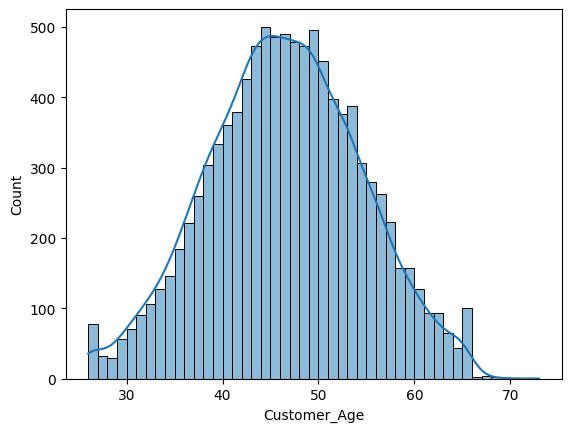

In [ ]:
sns.histplot(df['Customer_Age'], kde=True)
plt.show()

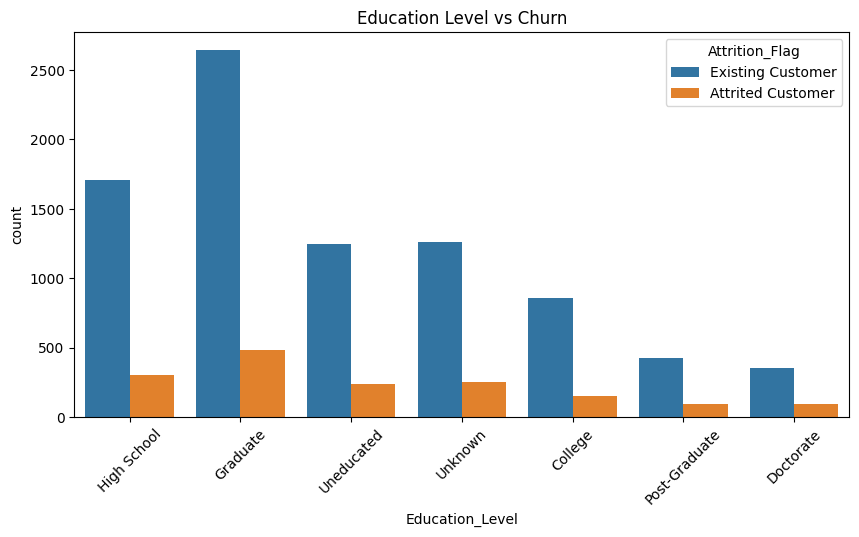

In [ ]:
#Education Level vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x=df['Education_Level'], hue=df['Attrition_Flag'])
plt.xticks(rotation=45)
plt.title("Education Level vs Churn")
plt.show()


<Figure size 2500x2000 with 0 Axes>

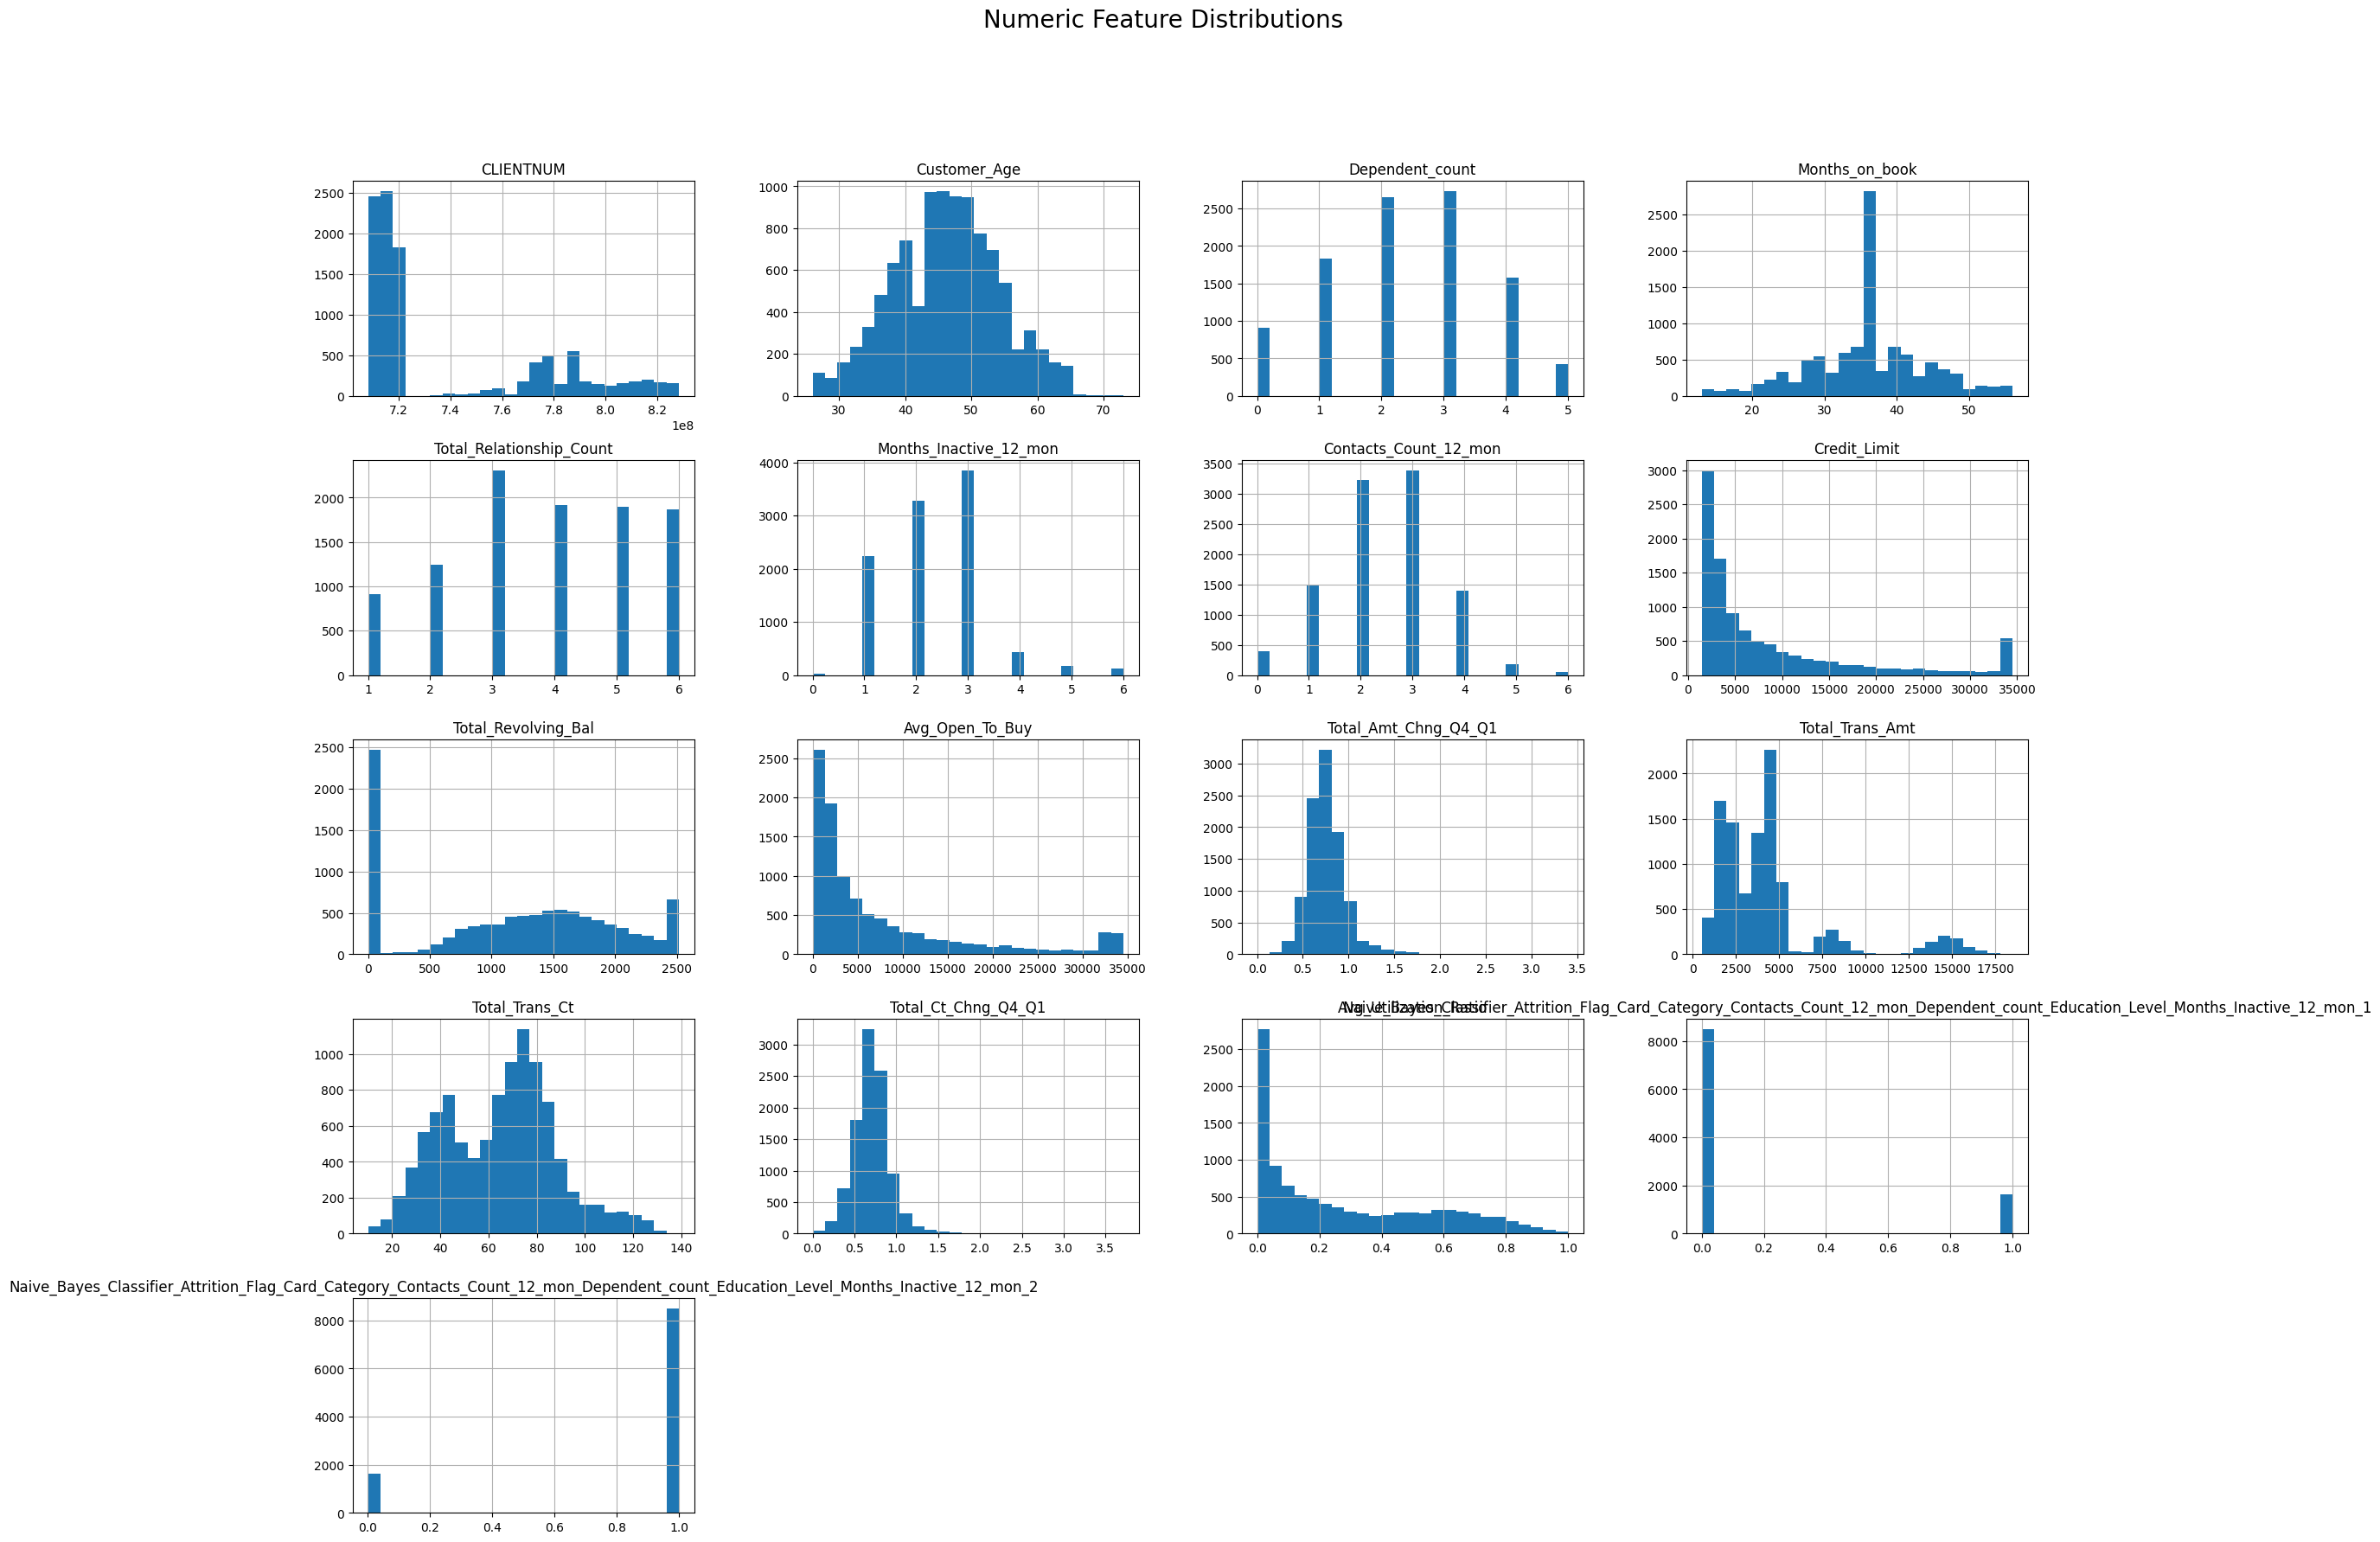

In [ ]:
#Numeric Feature Distribution
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(25,20))
df[numeric_cols].hist(figsize=(25,20), bins=25)
plt.suptitle("Numeric Feature Distributions", fontsize=20)
plt.show()


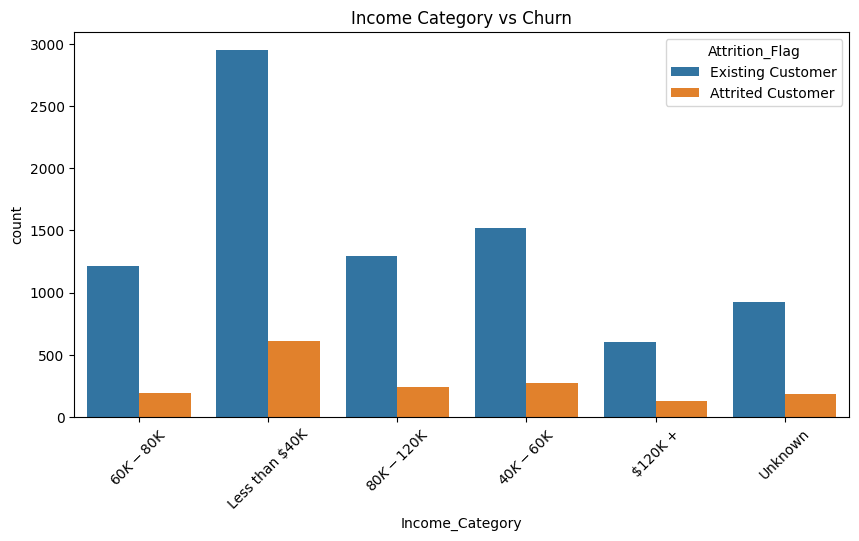

In [ ]:
#Income Category vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x=df['Income_Category'], hue=df['Attrition_Flag'])
plt.xticks(rotation=45)
plt.title("Income Category vs Churn")
plt.show()


/tmp/ipython-input-2455195034.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


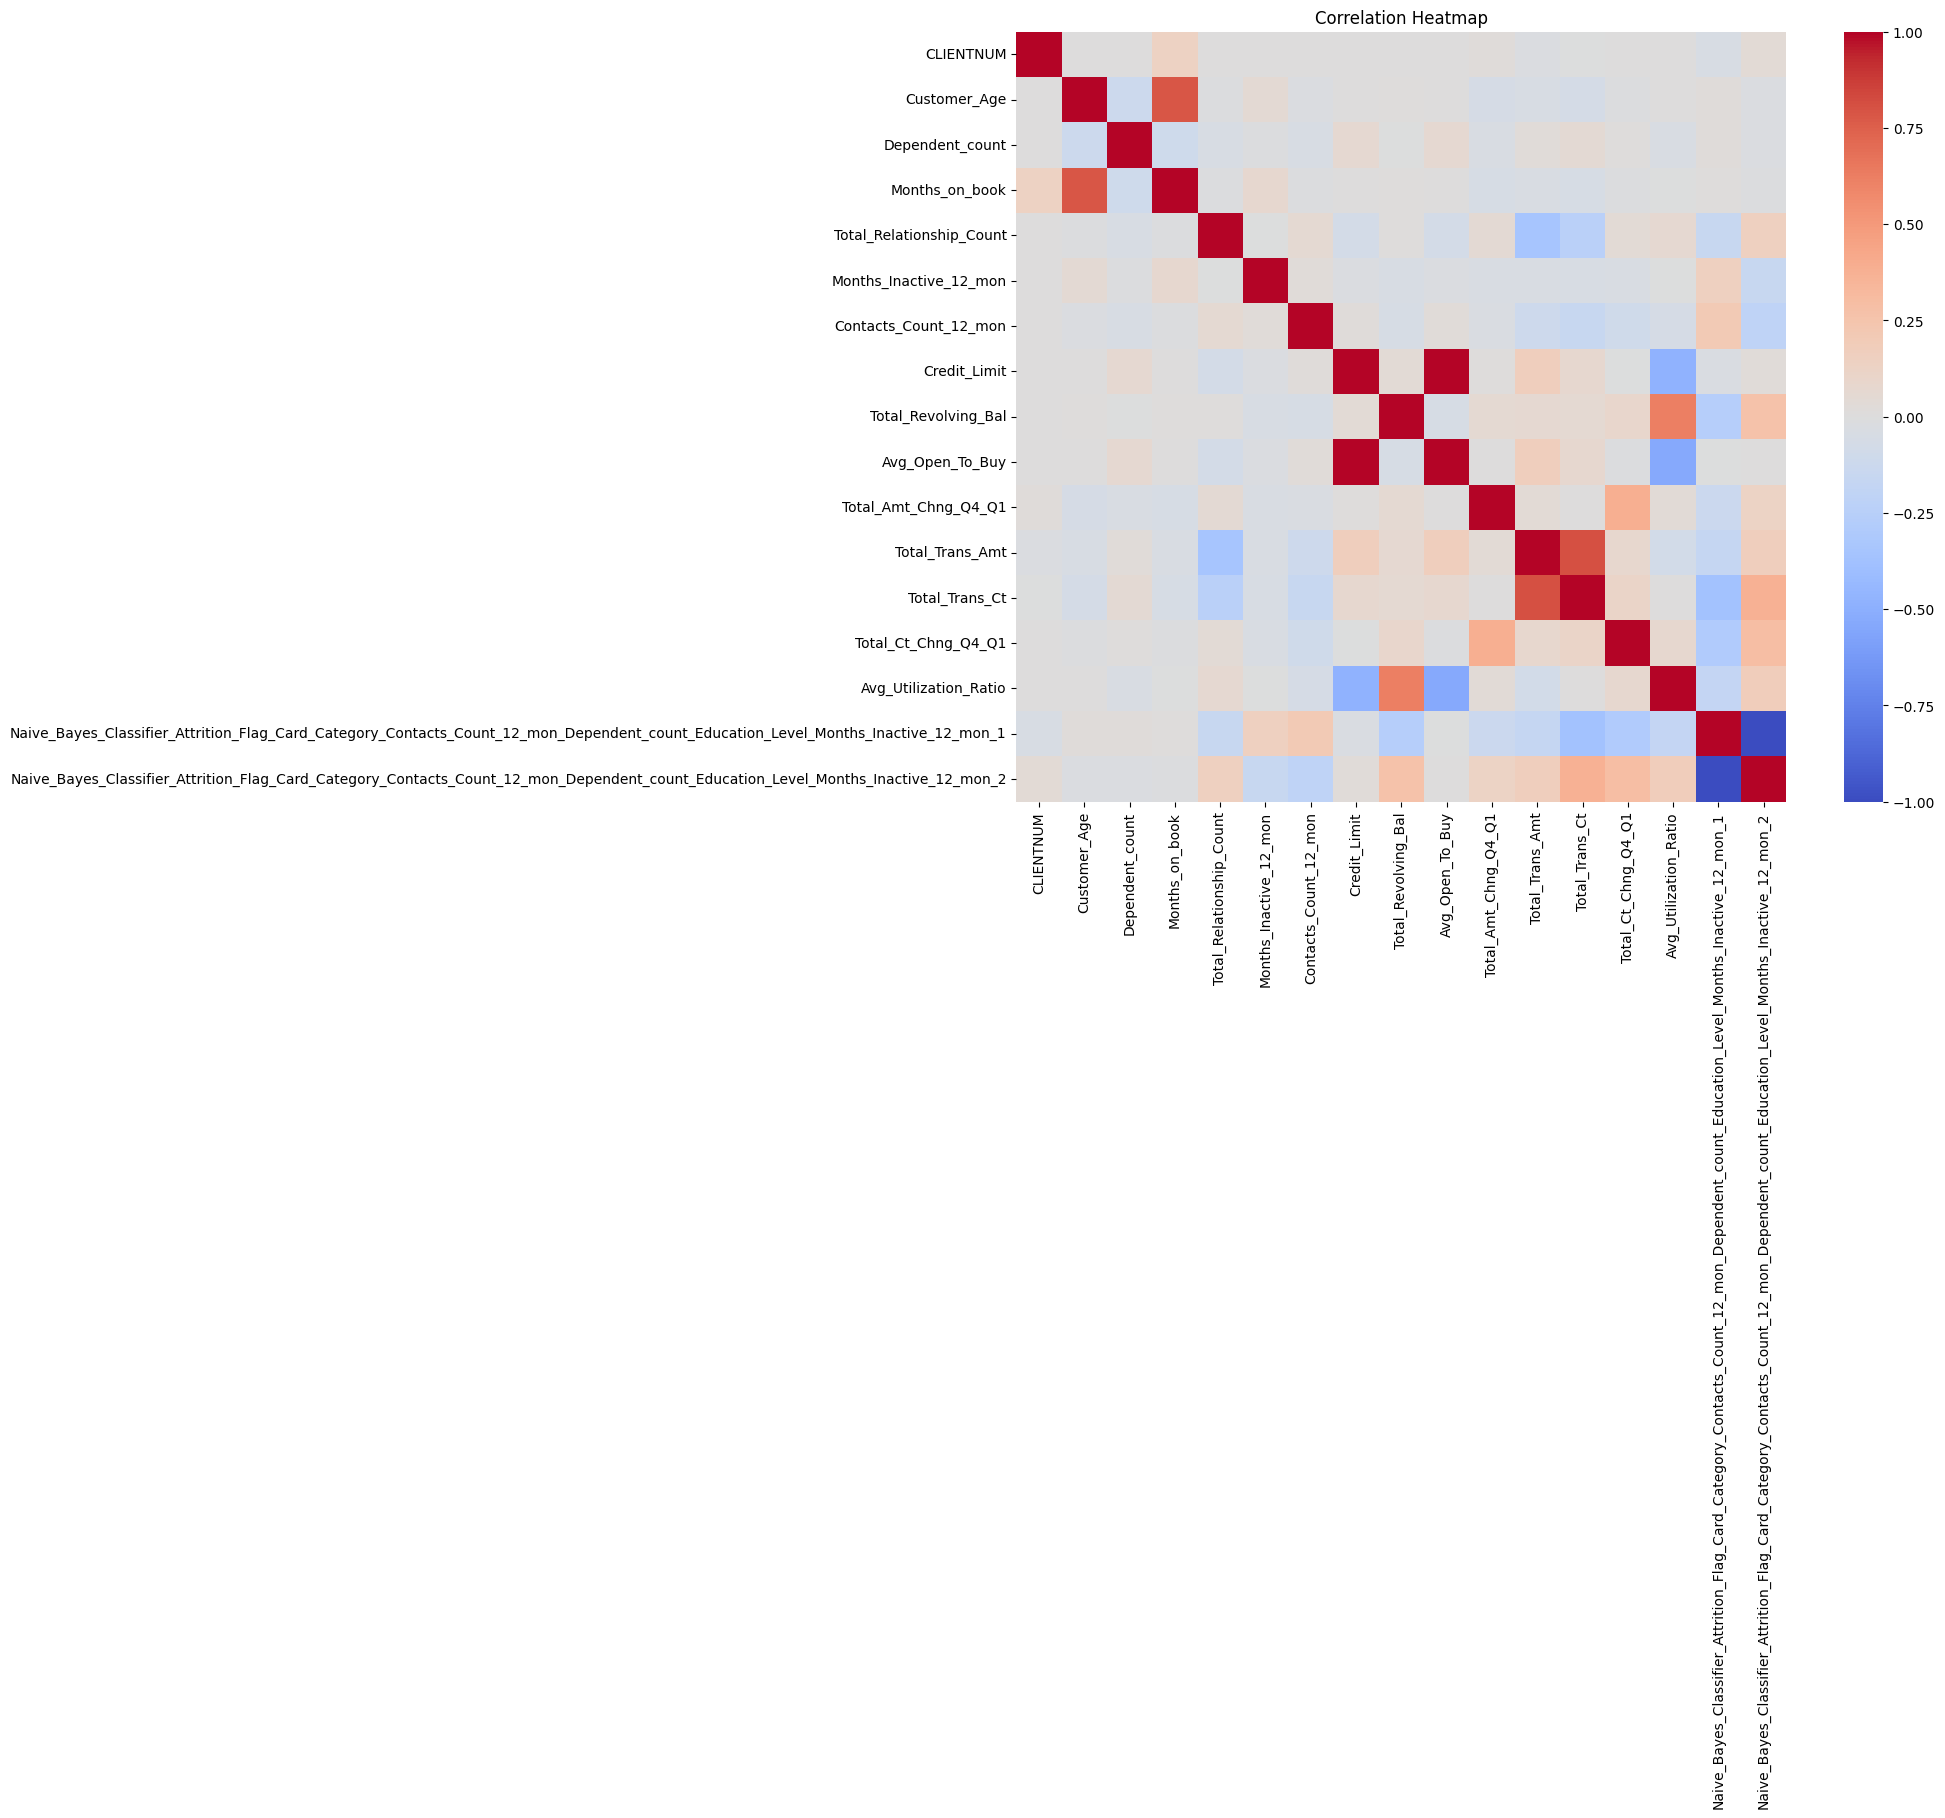

In [ ]:
plt.figure(figsize=(15,10))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()




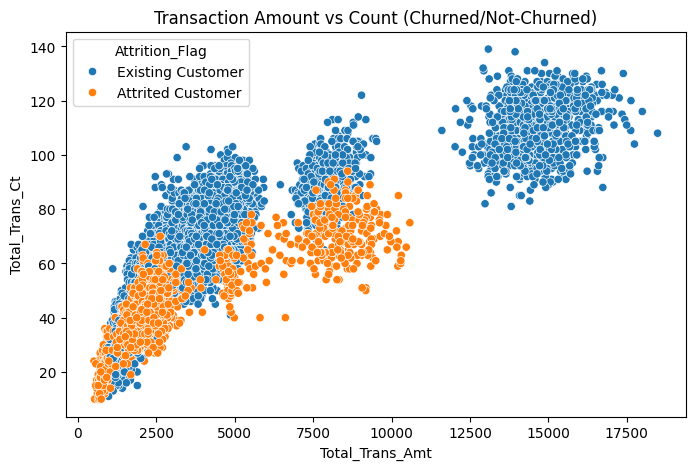

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Total_Trans_Amt'], y=df['Total_Trans_Ct'], hue=df['Attrition_Flag'])
plt.title("Transaction Amount vs Count (Churned/Not-Churned)")
plt.show()


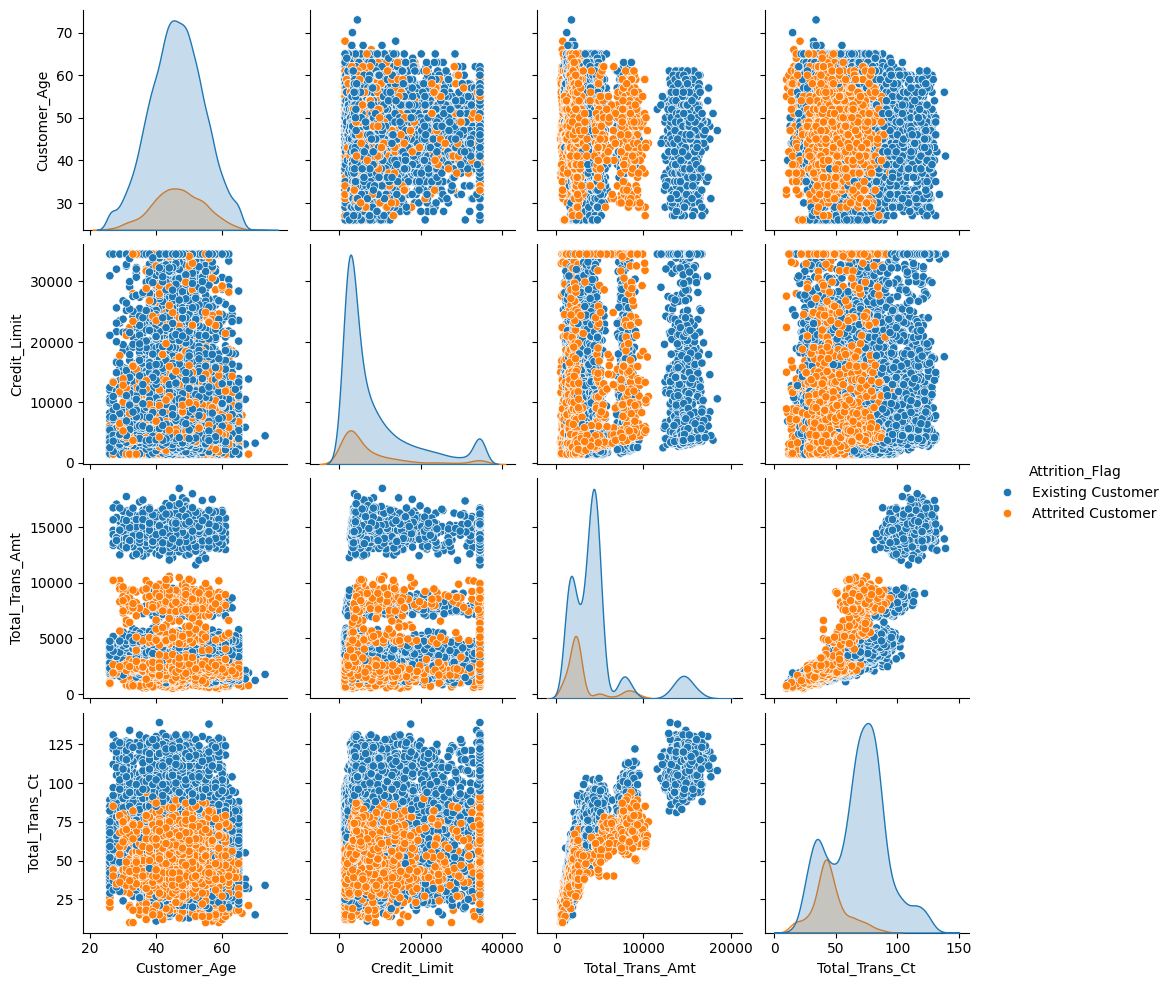

In [ ]:
sns.pairplot(df[['Customer_Age','Credit_Limit','Total_Trans_Amt','Total_Trans_Ct','Attrition_Flag']], hue='Attrition_Flag')
plt.show()


Class Percentage:
resampling Attrition_Flag
Existing Customer    8500
Attrited Customer    8500
Name: count, dtype: int64


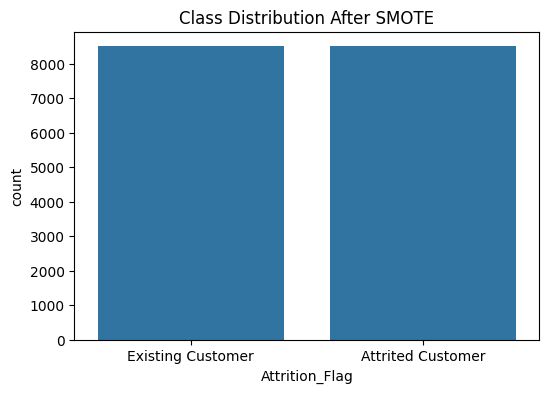

In [ ]:
#2. Check if there is an imbalance in data. If there is an imbalance in data, resolve it.
print("Class Percentage:")
in_bl = df['Attrition_Flag'].value_counts(normalize=True) * 100
in_bl

# Plot imbalance
# plt.figure(figsize=(6,4))
# sns.countplot(data=df, x='Attrition_Flag')
# plt.title("Class Distribution Before SMOTE")
# plt.show()
#FIX IMBALANCE (SMOTE)
X = df.drop(['Attrition_Flag', 'CLIENTNUM'], axis=1)
y = df['Attrition_Flag']

# Convert categorical columns to numeric (Label Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_encoded, y)
print('resampling',y_resampled.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title("Class Distribution After SMOTE")
plt.show()


In [ ]:
#3. Build a Logistic Regression classification model which will predict whether a customer is at risk to churn from the platform
X = df.drop(['CLIENTNUM', 'Attrition_Flag'], axis=1)
X_encoded = pd.get_dummies(X, drop_first=True)
y = df['Attrition_Flag']
X_resampled, y_resampled = sm.fit_resample(X_encoded, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


In [ ]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)
# Predictions
y_pred = log_reg.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 1.0

Classification Report:

                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00      1724
Existing Customer       1.00      1.00      1.00      1676

         accuracy                           1.00      3400
        macro avg       1.00      1.00      1.00      3400
     weighted avg       1.00      1.00      1.00      3400



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


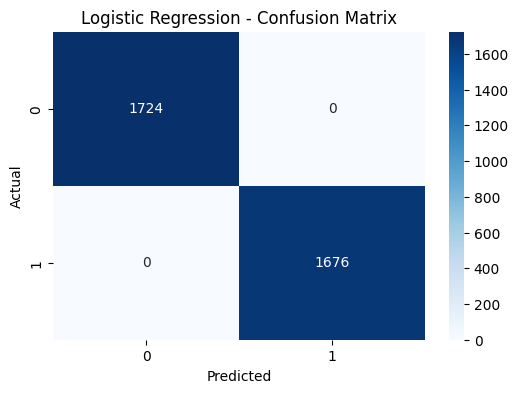

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#4. Build Naive Bayes model which will predict whether a customer is at risk to churn from the platform.
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 1.0
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00      1724
Existing Customer       1.00      1.00      1.00      1676

         accuracy                           1.00      3400
        macro avg       1.00      1.00      1.00      3400
     weighted avg       1.00      1.00      1.00      3400



In [ ]:
#5. Build a K-nearest classifier which will predict whether a customer is at risk to churn from the platform
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

knn_pred = knn.predict(X_test_s)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9979411764705882
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00      1724
Existing Customer       1.00      1.00      1.00      1676

         accuracy                           1.00      3400
        macro avg       1.00      1.00      1.00      3400
     weighted avg       1.00      1.00      1.00      3400



In [ ]:
#6. Find optimal parameters for the algorithm through GridSearchCV and build SVC model which will predict whether a customer is at risk to churn from the platform.
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(SVC(), param_grid_svc, cv=5, scoring='accuracy')
svc_grid.fit(X_train_s, y_train)

svc_pred = svc_grid.predict(X_test_s)

print("Best SVC Params:", svc_grid.best_params_)
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

Best SVC Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVC Accuracy: 1.0


In [ ]:
#7.Find optimal parameters for the algorithm through GridSearchCV and build a Decision tree which will predict whether a customer is at risk to churn from the platform.
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

dt_pred = dt_grid.predict(X_test)

print("Best DT Params:", dt_grid.best_params_)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
#print(classification_report(y_test, dt_pred))

Best DT Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Decision Tree Accuracy: 1.0


In [ ]:
#8.Find optimal parameters for the algorithm through RandomSearchCV and build aRandom which will predict whether a customer is at risk to churn from the platform.
param_dist_rf = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_rand = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

rf_rand.fit(X_train, y_train)
rf_pred = rf_rand.predict(X_test)

print("Best RF Params:", rf_rand.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Best RF Params: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Random Forest Accuracy: 1.0
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00      1724
Existing Customer       1.00      1.00      1.00      1676

         accuracy                           1.00      3400
        macro avg       1.00      1.00      1.00      3400
     weighted avg       1.00      1.00      1.00      3400



In [ ]:
#9. Model Selection: Evaluate and compare performance of all the models to find the best model.
results = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "SVC (GridSearch)": accuracy_score(y_test, svc_pred),
    "Decision Tree (GridSearch)": accuracy_score(y_test, dt_pred),
    "Random Forest (RandomSearch)": accuracy_score(y_test, rf_pred),
}

results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))


                          Model  Accuracy
0                   Naive Bayes  1.000000
2              SVC (GridSearch)  1.000000
3    Decision Tree (GridSearch)  1.000000
4  Random Forest (RandomSearch)  1.000000
1                           KNN  0.997941
